In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/crawford/80-cereals/cereal.csv


In [4]:
df=pd.read_csv(r'/kaggle/input/datasets/crawford/80-cereals/cereal.csv')

In [5]:
df

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,100% Bran,N,C,70,4,1,130,10.0,5.0,6,280,25,3,1.0,0.33,68.402973
1,100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8,135,0,3,1.0,1.00,33.983679
2,All-Bran,K,C,70,4,1,260,9.0,7.0,5,320,25,3,1.0,0.33,59.425505
3,All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0,330,25,3,1.0,0.50,93.704912
4,Almond Delight,R,C,110,2,2,200,1.0,14.0,8,-1,25,3,1.0,0.75,34.384843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,Triples,G,C,110,2,1,250,0.0,21.0,3,60,25,3,1.0,0.75,39.106174
73,Trix,G,C,110,1,1,140,0.0,13.0,12,25,25,2,1.0,1.00,27.753301
74,Wheat Chex,R,C,100,3,1,230,3.0,17.0,3,115,25,1,1.0,0.67,49.787445
75,Wheaties,G,C,100,3,1,200,3.0,17.0,3,110,25,1,1.0,1.00,51.592193


In [6]:
df.columns.isnull

<bound method Index.isna of Index(['name', 'mfr', 'type', 'calories', 'protein', 'fat', 'sodium', 'fiber',
       'carbo', 'sugars', 'potass', 'vitamins', 'shelf', 'weight', 'cups',
       'rating'],
      dtype='object')>

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      77 non-null     object 
 1   mfr       77 non-null     object 
 2   type      77 non-null     object 
 3   calories  77 non-null     int64  
 4   protein   77 non-null     int64  
 5   fat       77 non-null     int64  
 6   sodium    77 non-null     int64  
 7   fiber     77 non-null     float64
 8   carbo     77 non-null     float64
 9   sugars    77 non-null     int64  
 10  potass    77 non-null     int64  
 11  vitamins  77 non-null     int64  
 12  shelf     77 non-null     int64  
 13  weight    77 non-null     float64
 14  cups      77 non-null     float64
 15  rating    77 non-null     float64
dtypes: float64(5), int64(8), object(3)
memory usage: 9.8+ KB


In [8]:
df.shape

(77, 16)

## **The Purpose**
### **In this project we want to determine the effects of sugar on other features in the dataset it will entail our analysis of the sugar level by manufacturer , how sugar levels are related to the levels of nutrientsfound in cereals and how sugar levels are related to the ratings recieved by the cereals**

# **EDA**

## color pallete

In [9]:
palette=['#e6194B',
 '#3cb44b',
'#ffe119',
 '#4363d8',
 '#f58231',
 '#911eb4',
 '#42d4f4']

In [10]:
import matplotlib.pyplot as plt

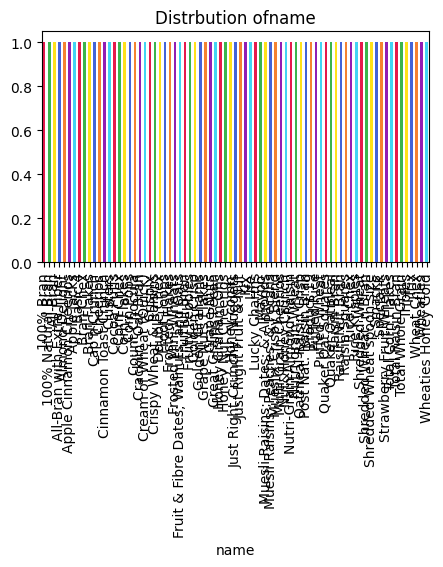

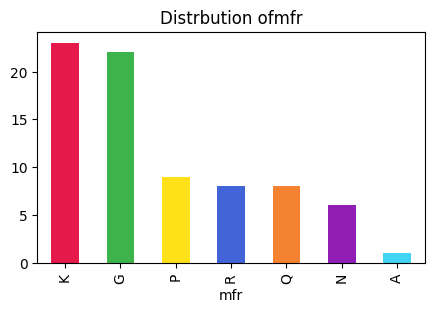

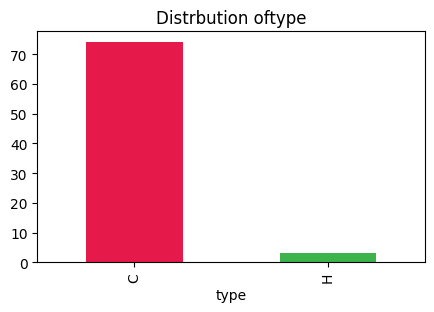

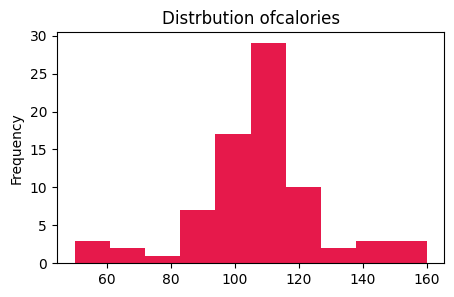

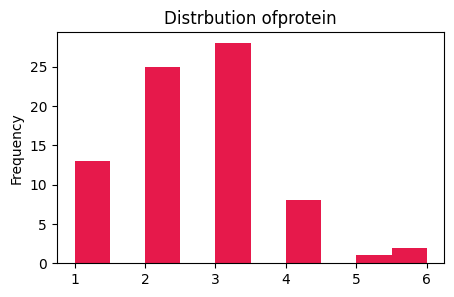

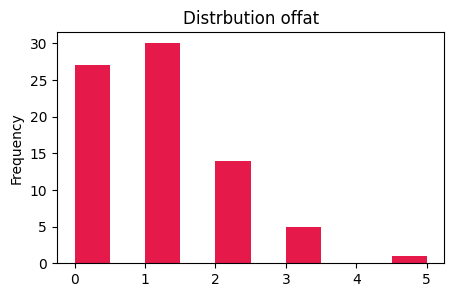

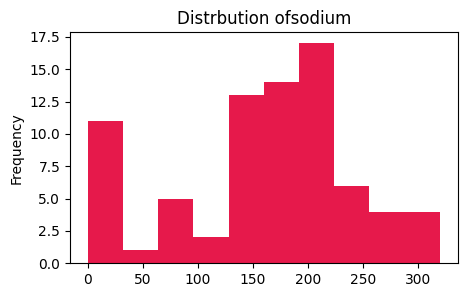

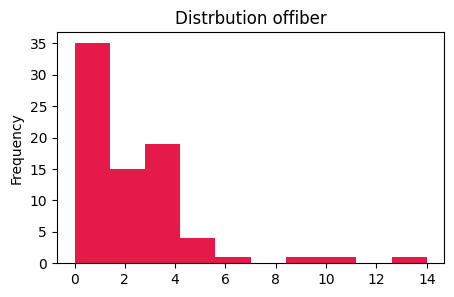

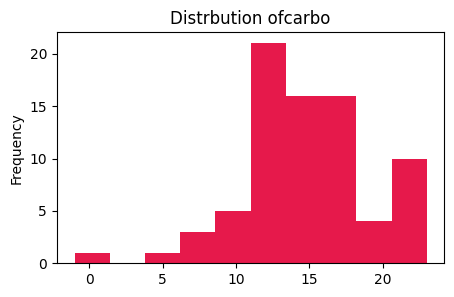

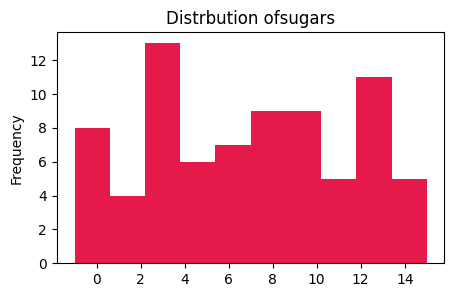

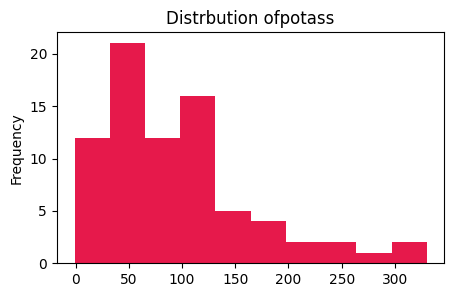

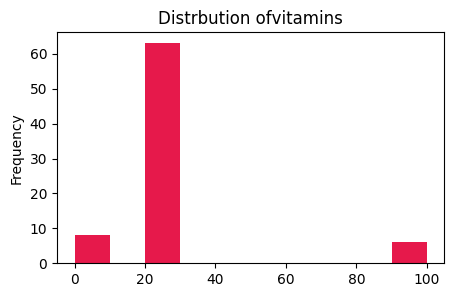

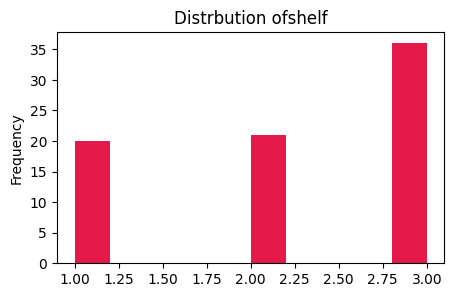

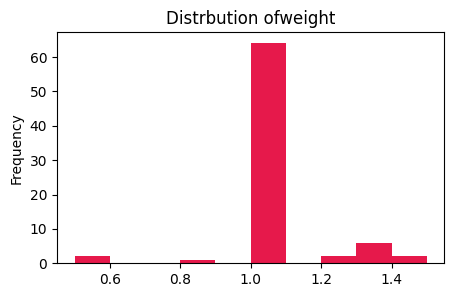

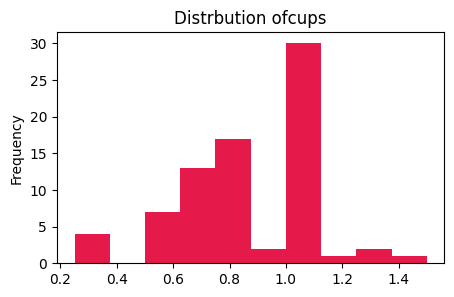

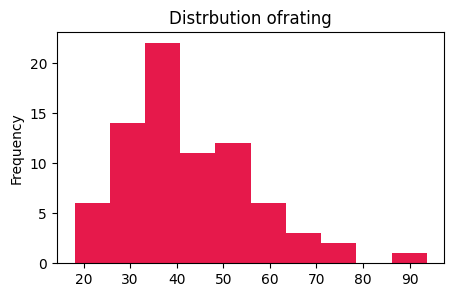

In [11]:
for feat in df.columns:
    plt.figure (figsize = (5,3))
    if df[feat].dtype == 'object':
        df[feat].value_counts().plot.bar(title=f'Distrbution of{feat}',color=palette)
    else : df[feat].plot.hist(title=f'Distrbution of{feat}',color=palette)
    plt.show()

In [12]:
df.columns

Index(['name', 'mfr', 'type', 'calories', 'protein', 'fat', 'sodium', 'fiber',
       'carbo', 'sugars', 'potass', 'vitamins', 'shelf', 'weight', 'cups',
       'rating'],
      dtype='object')

<Axes: title={'center': 'Sugar Level By Manufacturer'}, xlabel='mfr'>

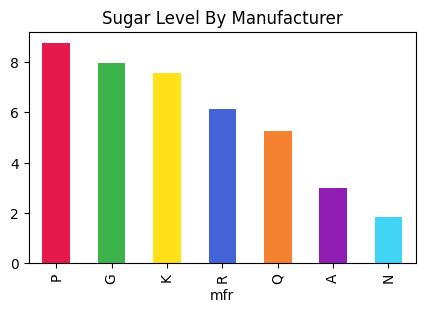

In [13]:
df.groupby('mfr')['sugars'].mean().sort_values(ascending = False).plot.bar(title="Sugar Level By Manufacturer",
                                                                   color =palette ,figsize = (5,3))

In [14]:
import seaborn as sns

In [15]:
order = df.groupby('mfr')['sugars'].mean().sort_values(ascending = False).index
print(order)

Index(['P', 'G', 'K', 'R', 'Q', 'A', 'N'], dtype='object', name='mfr')


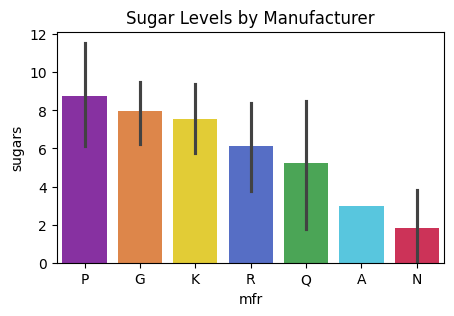

In [16]:
order = df.groupby('mfr')['sugars'].mean().sort_values(ascending = False).index
plt.figure(figsize=(5,3))
sns.barplot(data=df,x='mfr',y='sugars',hue='mfr',palette=palette,order=order)
plt.title('Sugar Levels by Manufacturer')
plt.show()

# The Black Vertical Lines (The Variation)
**1. Those thin black lines in the middle of each bar are called error bars. They tell you how much the sugar levels "spread out" across all products made by that company:**

**2. Long lines (like on P or Q): This means that manufacturer makes some products with very high sugar and some with much lower sugar. There is a lot of variety in their recipes.** 

**3. Short or no lines (like on A): This means most of their products have almost the same amount of sugar, or they might only have one product included in this data.**


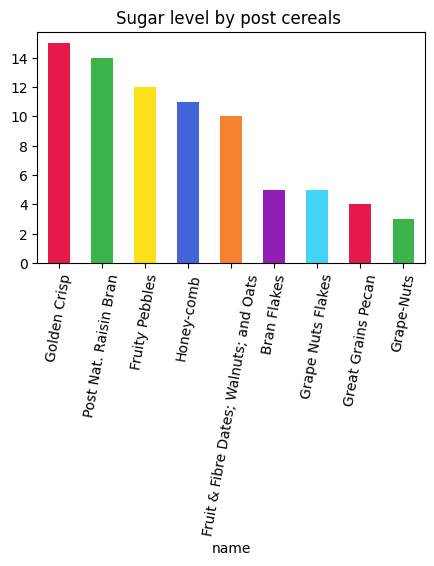

In [17]:
df_p= df[df['mfr']== 'P']
order = df_p.groupby('mfr')['sugars'].mean().sort_values(ascending = False).index
df_p.groupby('name')['sugars'].max().sort_values(ascending = False).plot.bar(
    title = 'Sugar level by post cereals ',color = palette ,figsize = (5,3))
plt.xticks(rotation=80)
plt.show()


In [18]:
df_p['name'].value_counts().index

Index(['Bran Flakes', 'Fruit & Fibre Dates; Walnuts; and Oats',
       'Fruity Pebbles', 'Golden Crisp', 'Grape Nuts Flakes', 'Grape-Nuts',
       'Great Grains Pecan', 'Honey-comb', 'Post Nat. Raisin Bran'],
      dtype='object', name='name')

In [19]:
df_p[df_p['name']=='Golden Crisp']['sugars']

30    15
Name: sugars, dtype: int64

In [20]:
df_p[df_p['name']=='Golden Crisp']['sugars'].values[0]

np.int64(15)

In [21]:
print(df_p['name'].unique())

['Bran Flakes' 'Fruit & Fibre Dates; Walnuts; and Oats' 'Fruity Pebbles'
 'Golden Crisp' 'Grape Nuts Flakes' 'Grape-Nuts' 'Great Grains Pecan'
 'Honey-comb' 'Post Nat. Raisin Bran']


In [22]:
value = df_p[df_p['name']=='Golden Crisp']['sugars'].values[0] - df_p[df_p['name']=='Grape-Nuts']['sugars'].values[0]
print(f'Diffrence in sugar between top and bottom: {value}')

Diffrence in sugar between top and bottom: 12


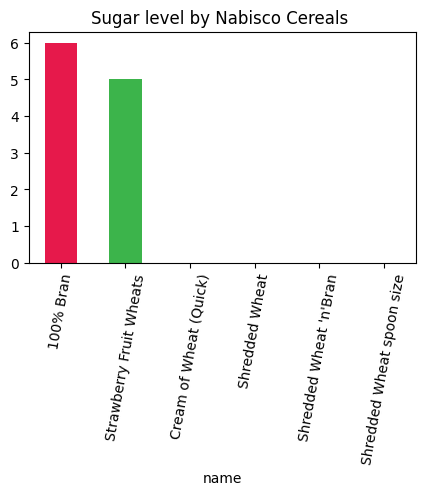

In [23]:
df_p= df[df['mfr']== 'N']
order = df_p.groupby('mfr')['sugars'].mean().sort_values(ascending = False).index
df_p.groupby('name')['sugars'].max().sort_values(ascending = False).plot.bar(
    title = 'Sugar level by Nabisco Cereals ',color = palette ,figsize = (5,3))
plt.xticks(rotation=80)
plt.show()

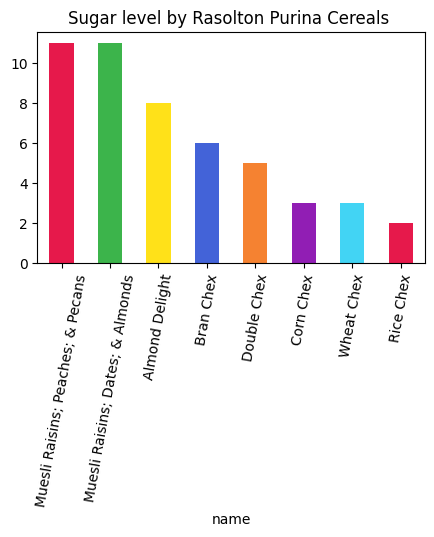

In [24]:
df_p= df[df['mfr']== 'R']
order = df_p.groupby('mfr')['sugars'].mean().sort_values(ascending = False).index
df_p.groupby('name')['sugars'].max().sort_values(ascending = False).plot.bar(
    title = 'Sugar level by Rasolton Purina Cereals ',color = palette ,figsize = (5,3))
plt.xticks(rotation=80)
plt.show()

### **Observation**
#### examining the Third manufacturer Rasolton Purina Cereals we find its other products having large range of other cereals also having products with cereals with less sugar content

/tmp/ipykernel_851/3230825228.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.displot(data=df ,x='sugars',hue='mfr',multiple='stack',kind='kde',height=2.5,aspect=1.7,palette=palette)


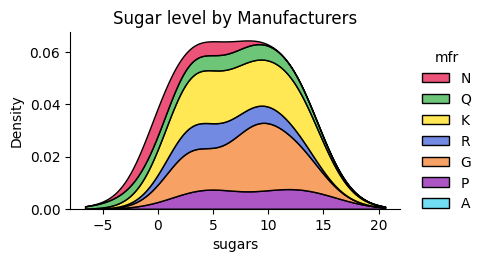

In [25]:
sns.displot(data=df ,x='sugars',hue='mfr',multiple='stack',kind='kde',height=2.5,aspect=1.7,palette=palette)
plt.title('Sugar level by Manufacturers')
plt.show()

### **observation**
1. ####   The Main Range: Most cereals contain between 0 and 15 units of sugar. There is a "double peak" in the overall data, meaning a lot of cereals fall into either a "lower sugar" group (around 5 units) or a "higher sugar" group (around 10 units).*
2. ####  Top Contributors: The largest colored areas are Yellow (K) and Orange (G). This indicates that manufacturers K and G likely have the highest number of cereal products represented in this data.
3. #### Manufacturer Differences: * Manufacturer G (Orange) and K (Yellow) have products spread across the entire sugar range, but they contribute heavily to the higher sugar levels (near 10).
   * #### Manufacturer P (Purple) has a relatively flat, low-density distribution, suggesting they have fewer products overall or a very consistent sugar level across their line.
   * #### Manufacturer N (Pink) and Q (Green) are mostly clustered at the top of the "stack," contributing to the overall volume but appearing less dominant than G or K.
4. #### In short: If you pick a cereal at random, it’s most likely to be from manufacturer G or K, and it will probably have either 5 or 10 grams of sugar.

In [26]:
#

# Correlation Between sugar and calories

<Axes: title={'center': 'Sugar vs calories'}, xlabel='sugars', ylabel='calories'>

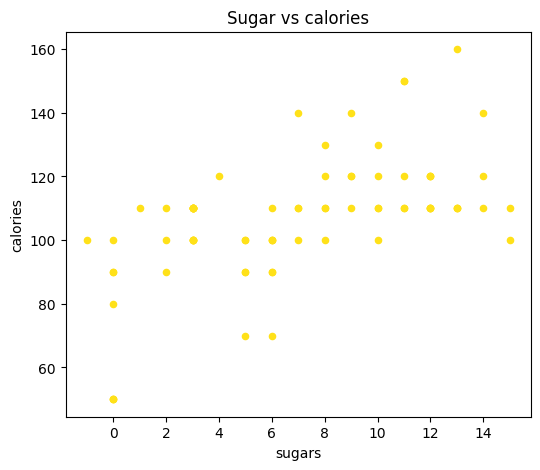

In [27]:
df.plot.scatter(x='sugars',y='calories',title='Sugar vs calories',c=palette[2],figsize=[6,5])

## Observation
#### 1. The General Trend: Upward Slant
**There is a positive correlation here. Generally, as the amount of sugar increases (moving right on the graph), the number of calories also tends to go up (moving up on the graph). This makes sense because sugar is a source of calories.**
#### 2. The "Sweet Spot" for Calories
**Most of the dots are clustered between 100 and 120 calories. Even when sugar levels vary significantly—anywhere from 1 unit to 15 units—many products still manage to stay within this calorie range.**
#### 3. Outliers (The Exceptions)
**High Sugar, High Calorie: In the top right, you can see a few dots reaching 140 to 160 calories. These are the "heavy hitters" that are very high in both sugar and total energy.**

**Low Sugar, Low Calorie: In the bottom left, there is one lone dot at 0 sugar and 50 calories. This is likely a very plain or puffed grain cereal.**

Sugar Level,Calorie Range,Observation
Low  (0–5), 50 – 120, Wide variety; some very light options.
Medium (6–10), 70 – 140, Most products sit right at 110 calories.
High (11–15), 100 – 160,  Higher floor; calories rarely drop below 100.

In [28]:
df[['sugars','calories']].corr()

,sugars,calories
sugars,1.00000,0.56234
calories,0.56234,1.00000


## Correlation Between Sugar and Rating 

In [29]:
df.columns

Index(['name', 'mfr', 'type', 'calories', 'protein', 'fat', 'sodium', 'fiber',
       'carbo', 'sugars', 'potass', 'vitamins', 'shelf', 'weight', 'cups',
       'rating'],
      dtype='object')

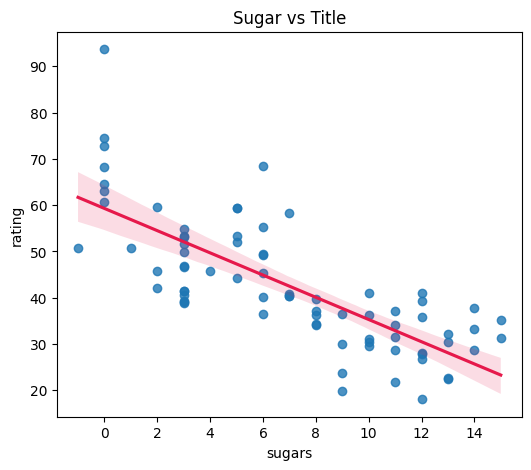

In [30]:
plt.figure(figsize=(6,5))
sns.regplot(data=df,x='sugars',y='rating',line_kws={'color':palette[0]})
plt.title('Sugar vs Title')
plt.show()

1. ### The Downward Slide (Negative Correlation)
The red line slopes downward from left to right. This shows a strong negative relationship: as sugar goes up, the rating goes down.

Low Sugar (0–3): Ratings are mostly high, often between 50 and 90.

High Sugar (12–15): Ratings are almost all low, mostly falling between 20 and 40.

2. ### The "Superstar" Outlier
Notice that one lone blue dot at the very top left (at 0 sugar). It has a rating of over 90. This is likely a very basic, high-fiber, or whole-grain cereal that is considered the "healthiest" in the bunch.

3. ### The Pink Shaded Area
The light pink "envelope" around the red line represents the confidence interval. Because it is relatively narrow, it means we can be quite confident that this downward trend is real and not just a random coincidence in the data


#### The pink shaded area (the "envelope" or "band") is a way of showing how much we can trust the red line. Think of it as a "margin of error" for the trend.

### In simple terms:

#### The Red Line: This is our "best guess" at the relationship. It says, "On average, if a cereal has 10 sugars, we expect its rating to be about 35."

#### The Pink Area: This represents the range where the true average likely sits. If the pink area is narrow, it means we have a lot of data and our "guess" (the red line) is very likely to be accurate.

#### If the Pink Area was Wide: It would mean the data is messy or we don't have enough of it, and we aren't really sure if the rating actually drops that way.

### Why does it get wider at the ends?
#### You might notice the pink area is slightly wider at the very beginning (left) and very end (right) of the sugar scale. This happens because there are fewer cereals with exactly 0 or exactly 15 sugars, so the math is a little less certain there than it is in the middle where most of the blue dots are clustered.

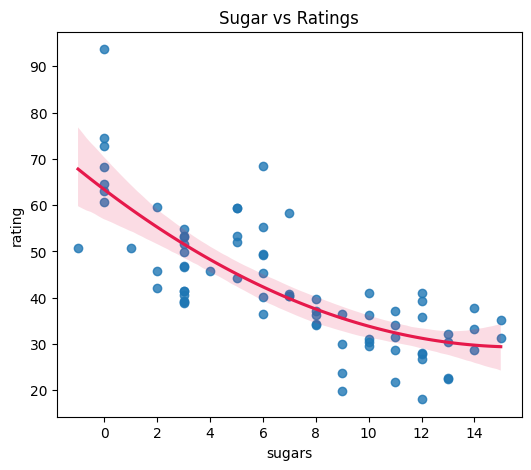

In [32]:
plt.figure(figsize=(6,5))
sns.regplot(data=df,x='sugars',y='rating',order=2,line_kws={'color':palette[0]})
plt.title('Sugar vs Ratings')
plt.show()

### By order = 2 we get more strong correlation

## Observation
#### *sugar  has negative correlation with rating And they are enot linear*
#### *sugar levels less than 8 have higher ratings*
#### *sugar levels more than 8 have lesser ratings*

## Sugar vs Vitamins

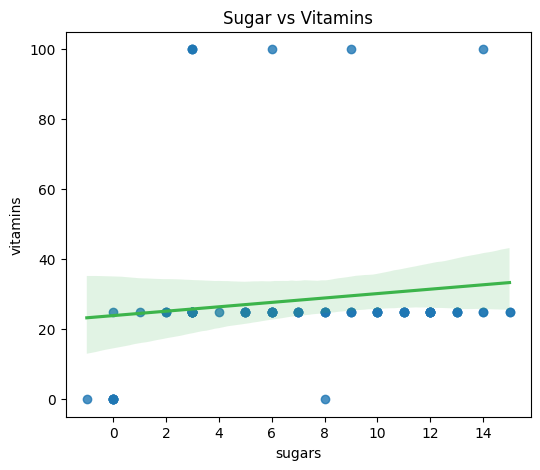

In [33]:
plt.figure(figsize=(6,5))
sns.regplot(data=df,x='sugars',y='vitamins',line_kws={'color':palette[1]})
plt.title('Sugar vs Vitamins')
plt.show()

### 1. No Real Relationship
**The green line is mostly flat. This means that knowing how much sugar is in a cereal doesn't really help you guess how many vitamins it has. A high-sugar cereal is just as likely to have vitamins as a low-sugar one**.

### 2. The "Standard" Amount
**Notice the long, straight row of blue dots at the 25 mark on the vitamin axis. This suggests that the vast majority of cereals are fortified with exactly the same amount of vitamins (likely 25% of the daily recommended value), regardless of their sugar content**.

### 3. The Outliers (The Dots at the Top and Bottom)
**The Top Dots (100): These are cereals that provide 100% of your daily vitamins. You can see they appear at various sugar levels (3, 6, 9, and 14)**

The Bottom Dots (0): A few cereals have zero vitamins added.

### 4. That Light Green Shaded Area (The "Maybe" Zone)
**Remember our talk about the "margin of error"? Notice how much wider this green shaded area is compared to the pink one from the last chart.**

**Because the dots are so scattered (some at 0, most at 25, some at 100), the computer is much less "confident" about its green trendline. The wide shaded area is basically the graph saying, "I'm drawing a line here, but the data is all over the place, so don't bank on this being a perfect rule."**